# vLLM Multi-Turn Benchmark with LMCache Offloading

**Clean Architecture Version**

This notebook provides a streamlined workflow for benchmarking vLLM with different CPU memory configurations.

## Architecture Overview

1. **Configuration Management**: Single source of truth for all parameters
2. **Execution**: Delegated to `run_benchmark.py` script
3. **Analysis**: Structured JSON results with advanced visualizations
4. **Reporting**: Interactive HTML reports and performance dashboards

## 1. Setup and Configuration

In [127]:
# Import required libraries
import json
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any
import subprocess

# Setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
pd.set_option('display.precision', 2)

In [128]:
# Get current working directory and change to target path
import os

print(f"📍 Original working directory: {os.getcwd()}")
os.chdir('/home/jding/vllm_multi_turn/benchmarks/')
print(f"📍 Changed working directory to: {os.getcwd()}")



📍 Original working directory: /home/jding/vllm_multi_turn/benchmarks
📍 Changed working directory to: /home/jding/vllm_multi_turn/benchmarks


In [129]:
# Load configuration from external YAML file
import hashlib
from datetime import datetime

# Load configuration from external file
CONFIG_FILE = 'benchmark_config_medium.yaml'

print(f"📄 Loading configuration from: {CONFIG_FILE}")
with open(CONFIG_FILE, 'r') as f:
    CONFIG = yaml.safe_load(f)

# Display loaded configuration
print(f"✅ Configuration loaded successfully")
print(f"   Model: {CONFIG['model']}")
print(f"   Conversations: {CONFIG['workload']['num_conversations']}")
print(f"   CPU sizes: {CONFIG['cpu_sizes']}")
print(f"   SSD sizes: {CONFIG['ssd_sizes']}")

# Generate unique run identifier based on config
def generate_run_id(config, offload_mode='cpu'):
    """Generate unique run ID based on configuration"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create a short hash from key config parameters
    key_params = {
        'num_conv': config['workload']['num_conversations'],
        'num_turns': config['workload']['prompt_input']['num_turns']['value'],
        'max_active': config['benchmark']['max_active_conversations'],
        'num_clients': config['benchmark']['num_clients'],
        'offload_mode': offload_mode,
        'sizes': sorted(config['ssd_sizes'] if offload_mode == 'ssd' else config['cpu_sizes'])
    }
    
    config_hash = hashlib.md5(str(key_params).encode()).hexdigest()[:6]
    
    # Create descriptive run ID
    run_id = f"run_{timestamp}_c{config['benchmark']['num_clients']}_ma{config['benchmark']['max_active_conversations']}_{offload_mode}_{config_hash}"
    
    return run_id

# Generate run ID for this execution (will run both CPU and SSD)
RUN_ID_CPU = generate_run_id(CONFIG, 'cpu')
RUN_ID_SSD = generate_run_id(CONFIG, 'ssd')

# Update paths with run-specific directories
CONFIG['paths']['output_dir_cpu'] = f'benchmark_results/{RUN_ID_CPU}'
CONFIG['paths']['output_dir_ssd'] = f'benchmark_results/{RUN_ID_SSD}'

# Create directories
for key, path in CONFIG['paths'].items():
    if 'dir' in key:
        Path(path).mkdir(parents=True, exist_ok=True)
    else:
        Path(path).parent.mkdir(parents=True, exist_ok=True)

print(f"🔑 CPU Run ID: {RUN_ID_CPU}")
print(f"🔑 SSD Run ID: {RUN_ID_SSD}")
print(f"📁 CPU output directory: {CONFIG['paths']['output_dir_cpu']}")
print(f"📁 SSD output directory: {CONFIG['paths']['output_dir_ssd']}")

📄 Loading configuration from: benchmark_config_large.yaml
✅ Configuration loaded successfully
   Model: meta-llama/Llama-3.1-8B-Instruct
   Conversations: 48
   CPU sizes: [-1, 450, 300, 200, 100, 0]
   SSD sizes: [450, 300, 200, 100]
🔑 CPU Run ID: run_20250927_165030_c2_ma48_cpu_e5650c
🔑 SSD Run ID: run_20250927_165030_c2_ma48_ssd_0d60be
📁 CPU output directory: benchmark_results/run_20250927_165030_c2_ma48_cpu_e5650c
📁 SSD output directory: benchmark_results/run_20250927_165030_c2_ma48_ssd_0d60be


In [130]:
def save_configs(config: Dict[str, Any]) -> tuple:
    """Save shared configuration files for both CPU and SSD runs"""
    # Create a shared configs directory with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    shared_config_dir = Path('configs') / f'run_{timestamp}'
    shared_config_dir.mkdir(parents=True, exist_ok=True)
    
    # Save workload config
    workload_path = shared_config_dir / 'workload.json'
    with open(workload_path, 'w') as f:
        json.dump(config['workload'], f, indent=2)
    
    # Save LMCache CPU template
    lmcache_path = shared_config_dir / 'lmcache_template.yaml'
    with open(lmcache_path, 'w') as f:
        yaml.dump(config['lmcache_template'], f, default_flow_style=False)
    
    # Save LMCache SSD template
    lmcache_ssd_path = shared_config_dir / 'lmcache_ssd_template.yaml'
    # Update SSD template with max of disk size or default CPU size
    ssd_template = config['lmcache_ssd_template'].copy()
    for size in config.get('ssd_sizes', []):
        if size > 0:
            ssd_template['max_local_cpu_size'] = max(size, 5)  # Ensure CPU size is at least 5GB or the disk size
            break
    
    with open(lmcache_ssd_path, 'w') as f:
        yaml.dump(ssd_template, f, default_flow_style=False)
    
    # Save the complete config used for this run
    full_config_path = shared_config_dir / 'full_config.yaml'
    with open(full_config_path, 'w') as f:
        config_snapshot = config.copy()
        config_snapshot['timestamp'] = datetime.now().isoformat()
        config_snapshot['cpu_run_id'] = RUN_ID_CPU
        config_snapshot['ssd_run_id'] = RUN_ID_SSD
        yaml.dump(config_snapshot, f, default_flow_style=False)
    
    # Also copy configs to each run directory for reference
    for run_id, output_dir in [(RUN_ID_CPU, CONFIG['paths']['output_dir_cpu']), 
                                 (RUN_ID_SSD, CONFIG['paths']['output_dir_ssd'])]:
        run_config_dir = Path(output_dir) / 'configs'
        run_config_dir.mkdir(parents=True, exist_ok=True)
        
        # Create a reference file pointing to shared configs
        reference_path = run_config_dir / 'config_reference.yaml'
        with open(reference_path, 'w') as f:
            reference = {
                'shared_config_dir': str(shared_config_dir),
                'run_id': run_id,
                'timestamp': datetime.now().isoformat(),
                'workload_config': str(workload_path),
                'lmcache_template': str(lmcache_path),
                'lmcache_ssd_template': str(lmcache_ssd_path),
                'full_config': str(full_config_path)
            }
            yaml.dump(reference, f, default_flow_style=False)
    
    print(f"✅ Saved shared configs in: {shared_config_dir}")
    print(f"   📄 Workload: {workload_path}")
    print(f"   📄 LMCache CPU: {lmcache_path}")
    print(f"   📄 LMCache SSD: {lmcache_ssd_path}")
    print(f"   📄 Full config: {full_config_path}")
    print(f"\n📌 Config references saved in:")
    print(f"   CPU: {CONFIG['paths']['output_dir_cpu']}/configs/config_reference.yaml")
    print(f"   SSD: {CONFIG['paths']['output_dir_ssd']}/configs/config_reference.yaml")
    
    return workload_path, lmcache_path, lmcache_ssd_path

# Save shared configurations
print("="*60)
print("Saving Shared Configuration Files")
print("="*60)
workload_config_path, lmcache_template_path, lmcache_ssd_template_path = save_configs(CONFIG)

Saving Shared Configuration Files
✅ Saved shared configs in: configs/run_20250927_165033
   📄 Workload: configs/run_20250927_165033/workload.json
   📄 LMCache CPU: configs/run_20250927_165033/lmcache_template.yaml
   📄 LMCache SSD: configs/run_20250927_165033/lmcache_ssd_template.yaml
   📄 Full config: configs/run_20250927_165033/full_config.yaml

📌 Config references saved in:
   CPU: benchmark_results/run_20250927_165030_c2_ma48_cpu_e5650c/configs/config_reference.yaml
   SSD: benchmark_results/run_20250927_165030_c2_ma48_ssd_0d60be/configs/config_reference.yaml


## 2. Execute Benchmarks

Run all benchmarks using the centralized script. This handles:
- Server lifecycle management
- Sequential benchmark execution
- Structured results output

In [131]:
# Build commands for both CPU and SSD offloading using shared configs
print("Commands to execute:")

# CPU command using shared config paths
cmd_cpu = [
    'python', 'run_benchmark.py',
    '--workload-config', str(workload_config_path),
    '--lmcache-template', str(lmcache_template_path),
    '--lmcache-ssd-template', str(lmcache_ssd_template_path),  # Include SSD template even for CPU
    '--cpu-sizes', *[str(s) for s in CONFIG['cpu_sizes']],
    '--output-dir', CONFIG['paths']['output_dir_cpu'],
    '--model', CONFIG['model'],
    '--benchmark-params', json.dumps(CONFIG['benchmark']),
    '--offload-mode', 'cpu'
]
print("\n1. CPU Offloading:")
print(' '.join(cmd_cpu))

# SSD command using shared config paths with page cache clearing
cmd_ssd = [
    'python', 'run_benchmark.py',
    '--workload-config', str(workload_config_path),
    '--lmcache-template', str(lmcache_template_path),
    '--lmcache-ssd-template', str(lmcache_ssd_template_path),
    '--cpu-sizes', *[str(s) for s in CONFIG['ssd_sizes']],  # Note: these are disk sizes for SSD mode
    '--output-dir', CONFIG['paths']['output_dir_ssd'],
    '--model', CONFIG['model'],
    '--benchmark-params', json.dumps(CONFIG['benchmark']),
    '--offload-mode', 'ssd',
    '--clear-cache-between-turns'  # Add page cache clearing for accurate SSD benchmarking
]

print("\n2. SSD Offloading (with page cache clearing):")
print(' '.join(cmd_ssd))

# Check if sudo is available for SSD benchmarks
import subprocess
try:
    result = subprocess.run(['sudo', '-n', 'true'], capture_output=True, timeout=1)
    if result.returncode == 0:
        print("\n✅ Passwordless sudo available for cache clearing")
    else:
        print("\n⚠️ Note: SSD benchmarks will need sudo access for page cache clearing")
        print("   Run with: sudo -E jupyter notebook OR setup passwordless sudo")
except:
    print("\n⚠️ sudo not available - SSD results may use cached data")

Commands to execute:

1. CPU Offloading:
python run_benchmark.py --workload-config configs/run_20250927_165033/workload.json --lmcache-template configs/run_20250927_165033/lmcache_template.yaml --lmcache-ssd-template configs/run_20250927_165033/lmcache_ssd_template.yaml --cpu-sizes -1 450 300 200 100 0 --output-dir benchmark_results/run_20250927_165030_c2_ma48_cpu_e5650c --model meta-llama/Llama-3.1-8B-Instruct --benchmark-params {"num_clients": 2, "max_active_conversations": 48, "warmup_step": false, "no_early_stop": true} --offload-mode cpu

2. SSD Offloading (with page cache clearing):
python run_benchmark.py --workload-config configs/run_20250927_165033/workload.json --lmcache-template configs/run_20250927_165033/lmcache_template.yaml --lmcache-ssd-template configs/run_20250927_165033/lmcache_ssd_template.yaml --cpu-sizes 450 300 200 100 --output-dir benchmark_results/run_20250927_165030_c2_ma48_ssd_0d60be --model meta-llama/Llama-3.1-8B-Instruct --benchmark-params {"num_clients": 

## 2.1 Execute CPU Offloading Benchmarks

Run this cell to execute CPU offloading benchmarks. This will test:
- HBM (GPU prefix caching)
- No cache (full recomputation)
- Various CPU memory sizes for offloading

In [ ]:
%%time
# Execute CPU offloading benchmarks
print("🚀 Starting CPU offloading benchmarks...\n")

print("="*60)
print("CPU OFFLOADING BENCHMARKS")
print("="*60)
print(f"Testing configurations:")
for size in CONFIG['cpu_sizes']:
    if size == -1:
        print(f"  • HBM (GPU prefix caching)")
    elif size == 0:
        print(f"  • No cache (full recomputation)")
    else:
        print(f"  • {size}GB CPU offloading")
print()

result_cpu = subprocess.run(cmd_cpu, capture_output=True, text=True)

if result_cpu.returncode == 0:
    print("✅ CPU benchmarks completed successfully!")
elif result_cpu.returncode == 2:
    print(f"❌ CRITICAL FAILURE: CPU benchmark servers failed to start (exit code {result_cpu.returncode})")
    print("Error output:")
    print(result_cpu.stderr)
elif result_cpu.returncode == 130:
    print("⚠️ CPU benchmarks interrupted by user (Ctrl+C)")
else:
    print(f"❌ CPU benchmarks failed with exit code {result_cpu.returncode}")
    print("Error output:")
    print(result_cpu.stderr)

# Display CPU output
print("\n" + "="*60)
print("CPU Benchmark Output (last 3000 chars):")
print("="*60)
print(result_cpu.stdout[-3000:])

print("\n" + "="*60)
print("CPU BENCHMARKS COMPLETED")
print("="*60)


# Execute SSD offloading benchmarks
print("🚀 Starting SSD offloading benchmarks...\n")

print("="*60)
print("SSD OFFLOADING BENCHMARKS")
print("="*60)
print(f"Testing configurations:")
for size in CONFIG['ssd_sizes']:
    print(f"  • {size}GB SSD offloading")
print()

result_ssd = subprocess.run(cmd_ssd, capture_output=True, text=True)

if result_ssd.returncode == 0:
    print("✅ SSD benchmarks completed successfully!")
elif result_ssd.returncode == 2:
    print(f"❌ CRITICAL FAILURE: SSD benchmark servers failed to start (exit code {result_ssd.returncode})")
    print("Error output:")
    print(result_ssd.stderr)
elif result_ssd.returncode == 130:
    print("⚠️ SSD benchmarks interrupted by user (Ctrl+C)")
else:
    print(f"❌ SSD benchmarks failed with exit code {result_ssd.returncode}")
    print("Error output:")
    print(result_ssd.stderr)

# Display SSD output
print("\n" + "="*60)
print("SSD Benchmark Output (last 3000 chars):")
print("="*60)
print(result_ssd.stdout[-3000:])

print("\n" + "="*60)
print("SSD BENCHMARKS COMPLETED")
print("="*60)

🚀 Starting CPU offloading benchmarks...

CPU OFFLOADING BENCHMARKS
Testing configurations:
  • HBM (GPU prefix caching)
  • 450GB CPU offloading
  • 300GB CPU offloading
  • 200GB CPU offloading
  • 100GB CPU offloading
  • No cache (full recomputation)



## 2.2 Execute SSD Offloading Benchmarks

Run this cell to execute SSD offloading benchmarks. This will test various SSD storage sizes with LMCache experimental features enabled.

In [116]:
%%time
# Execute SSD offloading benchmarks
print("🚀 Starting SSD offloading benchmarks...\n")

print("="*60)
print("SSD OFFLOADING BENCHMARKS")
print("="*60)
print(f"Testing configurations:")
for size in CONFIG['ssd_sizes']:
    print(f"  • {size}GB SSD offloading")
print()

result_ssd = subprocess.run(cmd_ssd, capture_output=True, text=True)

if result_ssd.returncode == 0:
    print("✅ SSD benchmarks completed successfully!")
elif result_ssd.returncode == 2:
    print(f"❌ CRITICAL FAILURE: SSD benchmark servers failed to start (exit code {result_ssd.returncode})")
    print("Error output:")
    print(result_ssd.stderr)
elif result_ssd.returncode == 130:
    print("⚠️ SSD benchmarks interrupted by user (Ctrl+C)")
else:
    print(f"❌ SSD benchmarks failed with exit code {result_ssd.returncode}")
    print("Error output:")
    print(result_ssd.stderr)

# Display SSD output
print("\n" + "="*60)
print("SSD Benchmark Output (last 3000 chars):")
print("="*60)
print(result_ssd.stdout[-3000:])

print("\n" + "="*60)
print("SSD BENCHMARKS COMPLETED")
print("="*60)

🚀 Starting SSD offloading benchmarks...

SSD OFFLOADING BENCHMARKS
Testing configurations:
  • 100GB SSD offloading

✅ SSD benchmarks completed successfully!

SSD Benchmark Output (last 3000 chars):


SSD BENCHMARKS COMPLETED
CPU times: user 71.8 ms, sys: 38.6 ms, total: 110 ms
Wall time: 20min 25s


## 3. Load and Process Results

In [133]:
## 2.1 Managing Multiple Benchmark Runs

# List all available benchmark runs
def list_benchmark_runs(base_dir='benchmark_results'):
    """List all available benchmark runs with their metadata"""
    base_path = Path(base_dir)
    runs = []
    
    if not base_path.exists():
        print(f"No benchmark results directory found: {base_dir}")
        return pd.DataFrame()
    
    # Recursively find all benchmark_summary.json files
    for summary_file in base_path.rglob('benchmark_summary.json'):
        with open(summary_file, 'r') as f:
            data = json.load(f)
            metadata = data.get('metadata', {})
            
            # Extract run directory name (parent of benchmark_summary.json)
            run_dir = summary_file.parent
            
            # Extract run info
            run_info = {
                'run_id': run_dir.name,
                'timestamp': metadata.get('timestamp', 'N/A'),
                'model': metadata.get('model', 'N/A'),
                'cpu_sizes': str(metadata.get('cpu_sizes', [])),
                'num_clients': metadata.get('benchmark_params', {}).get('num_clients', 'N/A'),
                'max_active': metadata.get('benchmark_params', {}).get('max_active_conversations', 'N/A'),
                'path': str(run_dir)
            }
            runs.append(run_info)
    
    if runs:
        df = pd.DataFrame(runs)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp', ascending=False)
        return df
    else:
        print("No benchmark runs found")
        return pd.DataFrame()

# Display available runs
available_runs = list_benchmark_runs()
if not available_runs.empty:
    print("📊 Available Benchmark Runs:")
    display(available_runs[['run_id', 'timestamp', 'num_clients', 'max_active', 'cpu_sizes']])
else:
    print("No benchmark runs available")

📊 Available Benchmark Runs:


,run_id,timestamp,num_clients,max_active,cpu_sizes
18,run_20250927_165030_c2_ma48_ssd_0d60be,2025-09-28 00:36:09.691623,2,48,"[450.0, 300.0, 200.0, 100.0]"
17,run_20250927_165030_c2_ma48_cpu_e5650c,2025-09-27 21:05:50.147448,2,48,"[-1.0, 450.0, 300.0, 200.0, 100.0, 0.0]"
16,run_20250927_054703_c2_ma24_ssd_f276cf,2025-09-27 07:58:58.197243,2,24,"[200.0, 100.0, 50.0]"
15,run_20250927_054703_c2_ma24_cpu_5a7a37,2025-09-27 06:56:41.947013,2,24,"[-1.0, 200.0, 100.0, 50.0, 0.0]"
14,run_20250927_043526_c2_ma24_ssd_7b5c9a,2025-09-27 05:02:23.846250,2,24,[100.0]
13,run_20250927_002647_c1_ma24_ssd_1b866e,2025-09-27 00:48:37.252133,1,24,[100.0]
12,run_20250918_232950_c2_ma24_ssd_7b5c9a,2025-09-18 23:43:19.752735,2,24,[100.0]
11,run_20250917_225944_c2_ma24_ssd_f276cf,2025-09-18 01:03:59.420933,2,24,"[200.0, 100.0, 50.0]"
10,run_20250917_225944_c2_ma24_cpu_5a7a37,2025-09-18 00:09:22.253655,2,24,"[-1.0, 200.0, 100.0, 50.0, 0.0]"
9,run_20250916_233622_c2_ma24_ssd_cea372,2025-09-16 23:45:30.988413,2,24,"[10.0, 5.0, 1.0]"


In [140]:
def load_benchmark_results(results_dir: str = None, run_id: str = None, 
                          cpu_path: str = None, ssd_path: str = None) -> Dict[str, Any]:
    """
    Load structured JSON results with flexible input options.
    
    Parameters:
    -----------
    results_dir : str, optional
        Legacy: directory containing benchmark_summary.json
    run_id : str, optional
        Load from a specific run ID in benchmark_results/
    cpu_path : str, optional
        Direct path to CPU offloading results (directory or JSON file)
    ssd_path : str, optional
        Direct path to SSD offloading results (directory or JSON file)
    
    Returns:
    --------
    Dict containing results with 'cpu' and/or 'ssd' keys, or single result dict
    
    Examples:
    ---------
    # Load current run (uses CONFIG paths)
    results = load_benchmark_results()
    
    # Load specific paths
    results = load_benchmark_results(
        cpu_path='benchmark_results/run_20250908_232242_c2_ma24_cpu_c16525',
        ssd_path='benchmark_results/run_20250908_232242_c2_ma24_ssd_cea372/run_20250908_232751_c2_ma24_ssd_be2063'
    )
    
    # Load only CPU results
    results = load_benchmark_results(cpu_path='path/to/cpu/results')
    
    # Load only SSD results  
    results = load_benchmark_results(ssd_path='path/to/ssd/results')
    
    # Load from run ID
    results = load_benchmark_results(run_id='run_20250908_232242_c2_ma24_cpu_c16525')
    """
    
    # Helper function to load from a path
    def load_from_path(path_str):
        path = Path(path_str)
        
        # If path is a JSON file, load directly
        if path.suffix == '.json':
            with open(path, 'r') as f:
                return json.load(f)
        
        # If path is a directory, look for benchmark_summary.json
        if path.is_dir():
            json_path = path / 'benchmark_summary.json'
            if json_path.exists():
                with open(json_path, 'r') as f:
                    return json.load(f)
            
            # Check for nested structure
            nested_runs = list(path.glob('run_*/benchmark_summary.json'))
            if nested_runs:
                with open(nested_runs[0], 'r') as f:
                    return json.load(f)
            
            raise FileNotFoundError(f"No benchmark_summary.json found in {path}")
        
        raise FileNotFoundError(f"Path does not exist: {path}")
    
    # Case 1: Direct CPU/SSD paths provided
    if cpu_path or ssd_path:
        results = {}
        
        if cpu_path:
            try:
                results['cpu'] = load_from_path(cpu_path)
                print(f"✅ Loaded CPU results from: {cpu_path}")
            except FileNotFoundError as e:
                print(f"❌ CPU results not found: {e}")
        
        if ssd_path:
            try:
                results['ssd'] = load_from_path(ssd_path)
                print(f"✅ Loaded SSD results from: {ssd_path}")
            except FileNotFoundError as e:
                print(f"❌ SSD results not found: {e}")
        
        if not results:
            raise FileNotFoundError("No results could be loaded from provided paths")
        
        return results
    
    # Case 2: Load from run_id
    if run_id:
        results_path = Path('benchmark_results') / run_id / 'benchmark_summary.json'
        if not results_path.exists():
            raise FileNotFoundError(f"Results not found: {results_path}")
        with open(results_path, 'r') as f:
            return json.load(f)
    
    # Case 3: Load from results_dir (backward compatibility)
    if results_dir:
        results_path = Path(results_dir) / 'benchmark_summary.json'
        if not results_path.exists():
            raise FileNotFoundError(f"Results not found: {results_path}")
        with open(results_path, 'r') as f:
            return json.load(f)
    
    # Case 4: Default - try to load from CONFIG paths (current run)
    results = {}
    
    # Load CPU results
    if 'output_dir_cpu' in CONFIG['paths']:
        cpu_path = Path(CONFIG['paths']['output_dir_cpu']) / 'benchmark_summary.json'
        if cpu_path.exists():
            with open(cpu_path, 'r') as f:
                results['cpu'] = json.load(f)
            print(f"✅ Loaded CPU results from: {RUN_ID_CPU}")
    
    # Load SSD results - check for nested structure
    if 'output_dir_ssd' in CONFIG['paths']:
        ssd_base = Path(CONFIG['paths']['output_dir_ssd'])
        ssd_path = ssd_base / 'benchmark_summary.json'
        
        if ssd_path.exists():
            with open(ssd_path, 'r') as f:
                results['ssd'] = json.load(f)
            print(f"✅ Loaded SSD results from: {RUN_ID_SSD}")
        else:
            # Check for nested structure
            nested_runs = list(ssd_base.glob('run_*/benchmark_summary.json'))
            if nested_runs:
                with open(nested_runs[0], 'r') as f:
                    results['ssd'] = json.load(f)
                print(f"✅ Loaded SSD results from nested: {nested_runs[0].parent.name}")
    
    if results:
        return results
    else:
        raise FileNotFoundError("No results found. Please provide paths or run benchmarks first.")

# Examples of how to use the updated function:
print("Loading results with various methods:\n")
print("="*60)

# Method 1: Load current run (default)
try:
    results_data = load_benchmark_results(
        cpu_path='benchmark_results/run_20250927_054703_c2_ma24_cpu_5a7a37/',
        ssd_path='benchmark_results/run_20250927_054703_c2_ma24_ssd_f276cf/'
        # cpu_path='benchmark_results/run_20250927_165030_c2_ma48_cpu_e5650c/',
        # ssd_path='benchmark_results/run_20250927_165030_c2_ma48_ssd_0d60be/'
    )
    if 'cpu' in results_data:
        print(f"📊 CPU Results: {len(results_data['cpu']['results'])} configurations")
    if 'ssd' in results_data:
        print(f"📊 SSD Results: {len(results_data['ssd']['results'])} configurations")
except FileNotFoundError as e:
    print(f"Default load failed: {e}")

print("\n" + "="*60)
print("Other usage examples (not executed):")
print("""
# Load specific paths:
results = load_benchmark_results(
    cpu_path='benchmark_results/run_20250908_232242_c2_ma24_cpu_c16525',
    ssd_path='benchmark_results/run_20250908_232242_c2_ma24_ssd_cea372/run_20250908_232751_c2_ma24_ssd_be2063'
)

# Load only CPU:
cpu_only = load_benchmark_results(cpu_path='path/to/cpu/results')

# Load only SSD:
ssd_only = load_benchmark_results(ssd_path='path/to/ssd/results')

# Load by run ID:
single_run = load_benchmark_results(run_id='run_20250908_232242_c2_ma24_cpu_c16525')

# Load JSON files directly:
results = load_benchmark_results(
    cpu_path='path/to/cpu/benchmark_summary.json',
    ssd_path='path/to/ssd/benchmark_summary.json'
)
""")

Loading results with various methods:

✅ Loaded CPU results from: benchmark_results/run_20250927_054703_c2_ma24_cpu_5a7a37/
✅ Loaded SSD results from: benchmark_results/run_20250927_054703_c2_ma24_ssd_f276cf/
📊 CPU Results: 5 configurations
📊 SSD Results: 3 configurations

Other usage examples (not executed):

# Load specific paths:
results = load_benchmark_results(
    cpu_path='benchmark_results/run_20250908_232242_c2_ma24_cpu_c16525',
    ssd_path='benchmark_results/run_20250908_232242_c2_ma24_ssd_cea372/run_20250908_232751_c2_ma24_ssd_be2063'
)

# Load only CPU:
cpu_only = load_benchmark_results(cpu_path='path/to/cpu/results')

# Load only SSD:
ssd_only = load_benchmark_results(ssd_path='path/to/ssd/results')

# Load by run ID:
single_run = load_benchmark_results(run_id='run_20250908_232242_c2_ma24_cpu_c16525')

# Load JSON files directly:
results = load_benchmark_results(
    cpu_path='path/to/cpu/benchmark_summary.json',
    ssd_path='path/to/ssd/benchmark_summary.json'
)



In [141]:
def create_performance_dataframe(results: Dict[str, Any]) -> pd.DataFrame:
    """Create DataFrame with performance metrics and derived values, supporting both CPU and SSD modes"""
    rows = []
    
    # Handle both single-result and multi-result formats
    if 'metadata' in results:
        # Single result format (legacy)
        results_list = [('cpu', results)]
    else:
        # Multi-result format (CPU and/or SSD)
        results_list = [(mode, data) for mode, data in results.items()]
    
    for mode, mode_results in results_list:
        for r in mode_results['results']:
            # Skip HBM results for main plotting (cpu_size == -1)
            if r['cpu_memory_size'] == -1:
                continue
            
            # Determine the actual memory size and type
            if mode == 'ssd' and r.get('disk_memory_size') is not None:
                memory_size = r['disk_memory_size']
            else:
                memory_size = r['cpu_memory_size']
            
            row = {
                'memory_size': memory_size,
                'offload_mode': mode,  # Always use the mode from the parent loop (cpu or ssd)
                'config_type': f"{mode.upper()} Offload" if r['cpu_memory_size'] > 0 else 'No Cache',
                'lmcache_hit_rate': r.get('lmcache_hit_rate', 0) if r.get('lmcache_hit_rate') is not None else 0,
                'lmcache_total_tokens': r.get('lmcache_total_tokens', 0),
                'lmcache_hit_tokens': r.get('lmcache_hit_tokens', 0),
                'requests_per_sec': r.get('requests_per_second', 0),
                'runtime': r.get('runtime', 0),
                'server_start_time': r.get('server_start_time', 0),
                'benchmark_duration': r.get('benchmark_duration', 0)
            }
            
            # Extract latency metrics with proper handling of dict structure
            for metric in ['ttft_ms', 'tpot_ms', 'latency_ms', 'input_num_tokens', 'output_num_tokens']:
                metric_data = r.get(metric, {})
                if metric_data:
                    # Add mean value for the metric
                    row[f'{metric}_mean'] = metric_data.get('mean', None)
                    # Add percentiles
                    for stat in ['min', '25%', '50%', '75%', '90%', '99%', 'max']:
                        row[f'{metric}_{stat}'] = metric_data.get(stat, None)
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Add derived metrics if we have the necessary columns
    if len(df) > 0 and 'ttft_ms_mean' in df.columns:
        # Calculate speedup separately for CPU and SSD modes
        for mode in df['offload_mode'].unique():
            mode_df = df[df['offload_mode'] == mode]
            
            # Find baseline (no cache or smallest memory size)
            no_cache_idx = mode_df[mode_df['memory_size'] == 0].index
            if len(no_cache_idx) > 0:
                baseline_idx = no_cache_idx[0]
            else:
                # Fallback to smallest memory size
                baseline_idx = mode_df['memory_size'].idxmin()
            
            if pd.notna(mode_df.loc[baseline_idx, 'ttft_ms_mean']):
                baseline_ttft = mode_df.loc[baseline_idx, 'ttft_ms_mean']
                df.loc[mode_df.index, 'ttft_speedup'] = baseline_ttft / mode_df['ttft_ms_mean']
        
        # Efficiency (requests per second per GB)
        if 'requests_per_sec' in df.columns:
            df['efficiency'] = df.apply(
                lambda row: row['requests_per_sec'] / row['memory_size'] if row['memory_size'] > 0 else None,
                axis=1
            )
        
        # Cache miss rate
        if 'lmcache_hit_rate' in df.columns:
            df['cache_miss_rate'] = 100 - df['lmcache_hit_rate']
    
    return df.sort_values(['offload_mode', 'memory_size'], ascending=[True, False])

# Create DataFrame
if results_data:
    df = create_performance_dataframe(results_data)
    print(f"\nCreated performance DataFrame with {len(df)} rows and {len(df.columns)} columns")
    print(f"Offload modes found: {list(df['offload_mode'].unique())}")
    print(f"Memory sizes by mode:")
    for mode in df['offload_mode'].unique():
        mode_sizes = sorted(df[df['offload_mode'] == mode]['memory_size'].unique(), reverse=True)
        print(f"  {mode.upper()}: {mode_sizes}")
    
    # Show summary by offload mode
    print("\n📊 Performance Summary by Offload Mode:")
    print("="*60)
    
    # Group by offload mode and show key metrics
    for mode in df['offload_mode'].unique():
        mode_df = df[df['offload_mode'] == mode]
        print(f"\n{mode.upper()} Offloading ({len(mode_df)} configurations):")
        summary_cols = ['memory_size', 'lmcache_hit_rate', 'ttft_ms_mean', 'requests_per_sec', 'runtime']
        print(mode_df[summary_cols].to_string(index=False))
    
    # Show HBM results separately if available
    if isinstance(results_data, dict):
        for mode, mode_results in results_data.items() if 'metadata' not in results_data else [('cpu', results_data)]:
            hbm_results = [r for r in mode_results['results'] if r['cpu_memory_size'] == -1]
            if hbm_results:
                print(f"\n📊 HBM (GPU Prefix Caching) Results for {mode.upper()} (baseline reference):")
                for r in hbm_results:
                    print(f"  TTFT Mean: {r.get('ttft_ms', {}).get('mean', 'N/A')} ms")
                    print(f"  Runtime: {r.get('runtime', 'N/A')} s")
                    print(f"  Requests/sec: {r.get('requests_per_second', 'N/A')}")
    
    print("\n📋 Full DataFrame (first 10 rows):")
    display(df.head(10))


Created performance DataFrame with 7 rows and 53 columns
Offload modes found: ['cpu', 'ssd']
Memory sizes by mode:
  CPU: [200.0, 100.0, 50.0, 0.0]
  SSD: [200.0, 100.0, 50.0]

📊 Performance Summary by Offload Mode:

CPU Offloading (4 configurations):
 memory_size  lmcache_hit_rate  ttft_ms_mean  requests_per_sec  runtime
       200.0             81.89       1597.49              0.96   249.99
       100.0             35.87       5327.17              0.35   687.97
        50.0              9.00       7087.19              0.27   891.56
         0.0              0.00       7130.31              0.27   892.88

SSD Offloading (3 configurations):
 memory_size  lmcache_hit_rate  ttft_ms_mean  requests_per_sec  runtime
       200.0             81.89       5595.20              0.23  1066.82
       100.0             35.60       7231.73              0.22  1078.86
        50.0              8.89       7901.31              0.23  1031.62

📊 HBM (GPU Prefix Caching) Results for CPU (baseline reference

,memory_size,offload_mode,config_type,lmcache_hit_rate,lmcache_total_tokens,lmcache_hit_tokens,requests_per_sec,runtime,server_start_time,benchmark_duration,...,output_num_tokens_min,output_num_tokens_25%,output_num_tokens_50%,output_num_tokens_75%,output_num_tokens_90%,output_num_tokens_99%,output_num_tokens_max,ttft_speedup,efficiency,cache_miss_rate
0,200.0,cpu,CPU Offload,81.89,6.90e+06,5.65e+06,0.96,249.99,132.52,257.13,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,4.46,4.80e-03,18.11
1,100.0,cpu,CPU Offload,35.87,6.90e+06,2.48e+06,0.35,687.97,106.43,694.39,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.34,3.49e-03,64.13
2,50.0,cpu,CPU Offload,9.00,6.90e+06,6.21e+05,0.27,891.56,90.37,899.16,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.01,5.38e-03,91.00
3,0.0,cpu,No Cache,0.00,NaN,NaN,0.27,892.88,70.31,899.31,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.00,NaN,100.00
4,200.0,ssd,SSD Offload,81.89,6.90e+06,5.65e+06,0.23,1066.82,132.50,1075.81,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.41,1.13e-03,18.11
5,100.0,ssd,SSD Offload,35.60,6.90e+06,2.46e+06,0.22,1078.86,146.56,1087.70,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.09,2.22e-03,64.40
6,50.0,ssd,SSD Offload,8.89,6.90e+06,6.14e+05,0.23,1031.62,148.57,1040.36,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.00,4.66e-03,91.11


## 4. Interactive Visualizations

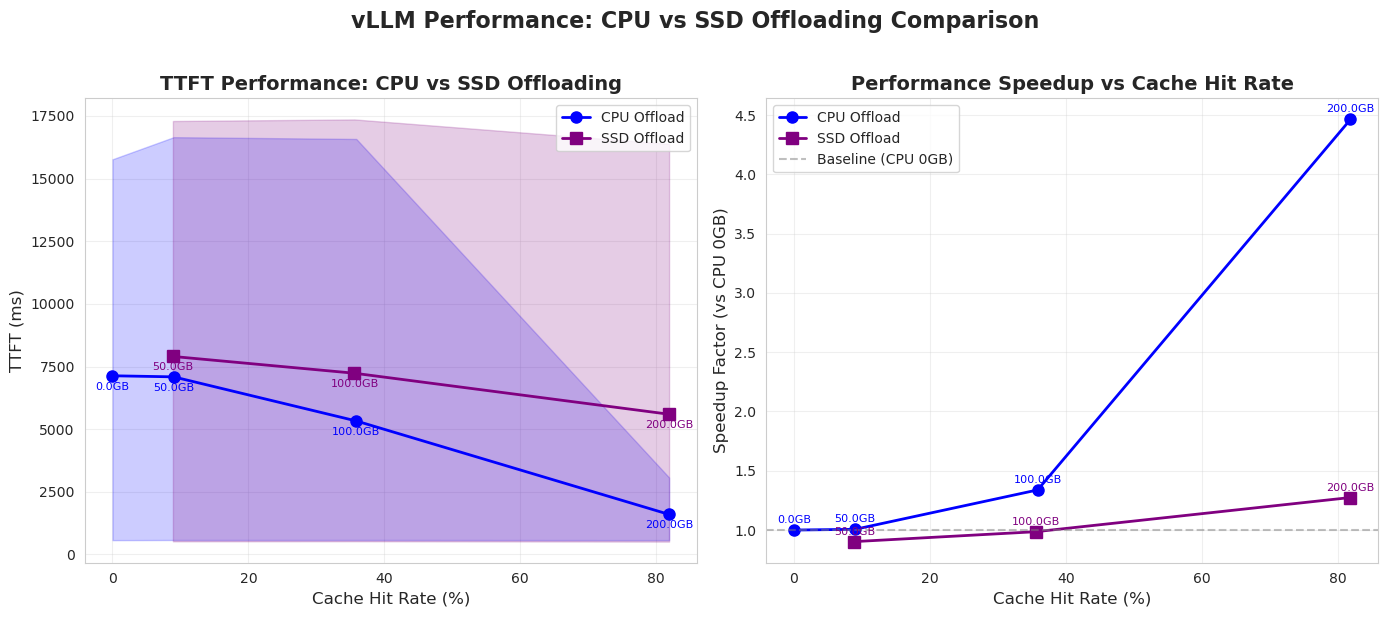


📊 Performance Comparison:
Baseline: CPU 0GB with TTFT = 7130.3ms


0.0GB Configuration:
  CPU - TTFT: 7130.3ms, Hit Rate: 0.0%, Speedup: 1.00x

50.0GB Configuration:
  CPU - TTFT: 7087.2ms, Hit Rate: 9.0%, Speedup: 1.01x
  SSD - TTFT: 7901.3ms, Hit Rate: 8.9%, Speedup: 0.90x
  → CPU is 11.5% faster than SSD

100.0GB Configuration:
  CPU - TTFT: 5327.2ms, Hit Rate: 35.9%, Speedup: 1.34x
  SSD - TTFT: 7231.7ms, Hit Rate: 35.6%, Speedup: 0.99x
  → CPU is 35.8% faster than SSD

200.0GB Configuration:
  CPU - TTFT: 1597.5ms, Hit Rate: 81.9%, Speedup: 4.46x
  SSD - TTFT: 5595.2ms, Hit Rate: 81.9%, Speedup: 1.27x
  → CPU is 250.2% faster than SSD


In [142]:
def create_comparison_visualizations(df: pd.DataFrame):
    """Create visualizations comparing CPU and SSD offloading with enhanced plots"""
    
    # Create subplots with better sizing
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            'TTFT Performance: CPU vs SSD Offloading',
            'Performance Speedup vs Cache Hit Rate (Baseline: CPU 0GB)'
        ),
        horizontal_spacing=0.15,
        specs=[[{'secondary_y': False}, {'secondary_y': False}]]
    )
    
    # Define colors for each mode
    colors = {
        'cpu': '#2E86AB',  # Blue for CPU
        'ssd': '#A23B72',  # Purple for SSD
        'none': '#F18F01' # Orange for no cache
    }
    
    # Get unique offload modes
    modes = df['offload_mode'].unique()
    
    # Find CPU 0GB baseline for speedup calculation
    cpu_0gb = df[(df['offload_mode'] == 'cpu') & (df['memory_size'] == 0)]
    if len(cpu_0gb) > 0:
        baseline_ttft = cpu_0gb['ttft_ms_mean'].values[0]
    else:
        # Fallback to smallest CPU configuration
        cpu_df = df[df['offload_mode'] == 'cpu']
        if len(cpu_df) > 0:
            baseline_ttft = cpu_df.loc[cpu_df['memory_size'].idxmin(), 'ttft_ms_mean']
        else:
            baseline_ttft = None
    
    # Track if we've shown legend for each mode
    legend_shown = set()
    
    # Plot 1: TTFT comparison with min/max envelope
    for mode in modes:
        mode_df = df[df['offload_mode'] == mode].sort_values('lmcache_hit_rate')
        
        if len(mode_df) > 0:
            # Add min/max envelope first (so it's behind the main line)
            if 'ttft_ms_min' in mode_df.columns and 'ttft_ms_max' in mode_df.columns:
                # Upper bound (max) - never show in legend
                fig.add_trace(
                    go.Scatter(
                        x=mode_df['lmcache_hit_rate'],
                        y=mode_df['ttft_ms_max'],
                        mode='lines',
                        name=f'{mode.upper()} max',
                        line=dict(color=colors.get(mode, '#666'), width=0),
                        showlegend=False,
                        hoverinfo='skip',
                        legendgroup=mode
                    ),
                    row=1, col=1
                )
                
                # Lower bound (min) - fill to max, never show in legend
                fig.add_trace(
                    go.Scatter(
                        x=mode_df['lmcache_hit_rate'],
                        y=mode_df['ttft_ms_min'],
                        mode='lines',
                        name=f'{mode.upper()} range',
                        line=dict(color=colors.get(mode, '#666'), width=0),
                        fill='tonexty',
                        fillcolor=f"rgba({int(colors.get(mode, '#666')[1:3], 16)}, "
                                 f"{int(colors.get(mode, '#666')[3:5], 16)}, "
                                 f"{int(colors.get(mode, '#666')[5:7], 16)}, 0.2)",
                        hovertemplate='Min: %{y:.1f}ms<extra></extra>',
                        legendgroup=mode,
                        showlegend=False
                    ),
                    row=1, col=1
                )
            
            # Main TTFT line - show legend only once per mode
            fig.add_trace(
                go.Scatter(
                    x=mode_df['lmcache_hit_rate'],
                    y=mode_df['ttft_ms_mean'],
                    mode='lines+markers',
                    name=f'{mode.upper()} Offload',
                    line=dict(color=colors.get(mode, '#666'), width=3),
                    marker=dict(size=10, symbol='circle' if mode == 'cpu' else 'square', 
                              line=dict(width=2, color='white')),
                    text=[f"{size:.1f}GB" for size in mode_df['memory_size']],
                    hovertemplate='<b>%{text}</b><br>Hit Rate: %{x:.1f}%<br>TTFT Mean: %{y:.1f}ms<extra></extra>',
                    legendgroup=mode,
                    showlegend=True  # Show legend for first plot
                ),
                row=1, col=1
            )
            legend_shown.add(mode)
            
            # Add memory size labels
            for i, row in mode_df.iterrows():
                fig.add_annotation(
                    x=row['lmcache_hit_rate'],
                    y=row['ttft_ms_mean'],
                    text=f"{row['memory_size']:.1f}GB",
                    showarrow=False,
                    font=dict(size=9, color=colors.get(mode, '#666')),
                    bgcolor='rgba(255, 255, 255, 0.8)',
                    bordercolor=colors.get(mode, '#666'),
                    borderwidth=1,
                    xshift=0,
                    yshift=-15,
                    row=1, col=1
                )
    
    # Plot 2: Performance Speedup vs Cache Hit Rate (using CPU 0GB as baseline)
    if baseline_ttft is not None:
        for mode in modes:
            mode_df = df[df['offload_mode'] == mode].sort_values('lmcache_hit_rate')
            
            if len(mode_df) > 0:
                # Calculate speedup relative to CPU 0GB baseline
                speedup = baseline_ttft / mode_df['ttft_ms_mean']
                
                # Never show legend for second plot (use same legendgroup)
                fig.add_trace(
                    go.Scatter(
                        x=mode_df['lmcache_hit_rate'],
                        y=speedup,
                        mode='lines+markers',
                        name=f'{mode.upper()} Offload',
                        line=dict(color=colors.get(mode, '#666'), width=3),
                        marker=dict(size=10, 
                                  symbol='circle' if mode == 'cpu' else 'square',
                                  line=dict(width=2, color='white')),
                        text=[f"{size:.1f}GB" for size in mode_df['memory_size']],
                        hovertemplate='<b>%{text}</b><br>Hit Rate: %{x:.1f}%<br>Speedup: %{y:.2f}x<extra></extra>',
                        legendgroup=mode,  # Same legendgroup as plot 1
                        showlegend=False   # Never show legend for plot 2
                    ),
                    row=1, col=2
                )
                
                # Add memory size labels for speedup plot
                for i, (idx, row) in enumerate(mode_df.iterrows()):
                    fig.add_annotation(
                        x=row['lmcache_hit_rate'],
                        y=speedup.iloc[i],
                        text=f"{row['memory_size']:.1f}GB",
                        showarrow=False,
                        font=dict(size=9, color=colors.get(mode, '#666')),
                        bgcolor='rgba(255, 255, 255, 0.8)',
                        bordercolor=colors.get(mode, '#666'),
                        borderwidth=1,
                        xshift=0,
                        yshift=-15,
                        row=1, col=2
                    )
        
        # Add reference line at speedup = 1
        fig.add_hline(y=1.0, line_dash="dash", line_color="gray", 
                     annotation_text="Baseline (CPU 0GB)", 
                     annotation_position="left",
                     row=1, col=2)
    
    # Update layout
    fig.update_layout(
        height=600,
        width=1400,
        showlegend=True,
        title_text="vLLM Performance: CPU vs SSD Offloading Comparison",
        title_font_size=20,
        title_x=0.5,
        hovermode='closest',
        margin=dict(t=100, b=80, l=80, r=80),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            font=dict(size=12)
        ),
        paper_bgcolor='white',
        plot_bgcolor='#F8F9FA'
    )
    
    # Update axes
    fig.update_xaxes(
        title_text="Cache Hit Rate (%)", 
        title_font_size=14,
        tickfont_size=12,
        gridcolor='lightgray',
        gridwidth=1,
        row=1, col=1
    )
    fig.update_yaxes(
        title_text="Time to First Token (ms)", 
        title_font_size=14,
        tickfont_size=12,
        gridcolor='lightgray',
        gridwidth=1,
        row=1, col=1
    )
    
    fig.update_xaxes(
        title_text="Cache Hit Rate (%)", 
        title_font_size=14,
        tickfont_size=12,
        gridcolor='lightgray',
        gridwidth=1,
        row=1, col=2
    )
    fig.update_yaxes(
        title_text="Speedup Factor (vs CPU 0GB)", 
        title_font_size=14,
        tickfont_size=12,
        gridcolor='lightgray',
        gridwidth=1,
        row=1, col=2
    )
    
    return fig

# Create and display the comparison visualizations
if results_data and df is not None:
    comparison_fig = create_comparison_visualizations(df)
    comparison_fig.show()
    
    # Also create a matplotlib version for better static export
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Find CPU 0GB baseline
    cpu_0gb = df[(df['offload_mode'] == 'cpu') & (df['memory_size'] == 0)]
    if len(cpu_0gb) > 0:
        baseline_ttft = cpu_0gb['ttft_ms_mean'].values[0]
    else:
        cpu_df = df[df['offload_mode'] == 'cpu']
        baseline_ttft = cpu_df.loc[cpu_df['memory_size'].idxmin(), 'ttft_ms_mean'] if len(cpu_df) > 0 else None
    
    # Plot 1: TTFT comparison with min/max envelope
    ax1 = axes[0]
    for mode in df['offload_mode'].unique():
        mode_df = df[df['offload_mode'] == mode].sort_values('lmcache_hit_rate')
        if len(mode_df) > 0:
            color = {'cpu': 'blue', 'ssd': 'purple', 'none': 'orange'}.get(mode, 'gray')
            marker = {'cpu': 'o', 'ssd': 's', 'none': '^'}.get(mode, 'o')
            
            # Add min/max envelope
            if 'ttft_ms_min' in mode_df.columns and 'ttft_ms_max' in mode_df.columns:
                ax1.fill_between(mode_df['lmcache_hit_rate'], 
                               mode_df['ttft_ms_min'], 
                               mode_df['ttft_ms_max'],
                               alpha=0.2, color=color)
            
            # Main line
            ax1.plot(mode_df['lmcache_hit_rate'], mode_df['ttft_ms_mean'], 
                    f'-{marker}', color=color, linewidth=2, markersize=8, 
                    label=f'{mode.upper()} Offload')
            
            # Add labels
            for i, row in mode_df.iterrows():
                ax1.annotate(f'{row["memory_size"]:.1f}GB', 
                           xy=(row['lmcache_hit_rate'], row['ttft_ms_mean']),
                           xytext=(0, -10), textcoords='offset points', 
                           fontsize=8, ha='center', color=color)
    
    ax1.set_xlabel('Cache Hit Rate (%)', fontsize=12)
    ax1.set_ylabel('TTFT (ms)', fontsize=12)
    ax1.set_title('TTFT Performance: CPU vs SSD Offloading', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Speedup vs Cache Hit Rate
    ax2 = axes[1]
    if baseline_ttft is not None:
        for mode in df['offload_mode'].unique():
            mode_df = df[df['offload_mode'] == mode].sort_values('lmcache_hit_rate')
            if len(mode_df) > 0:
                color = {'cpu': 'blue', 'ssd': 'purple', 'none': 'orange'}.get(mode, 'gray')
                marker = {'cpu': 'o', 'ssd': 's', 'none': '^'}.get(mode, 'o')
                
                # Calculate speedup
                speedup = baseline_ttft / mode_df['ttft_ms_mean']
                
                ax2.plot(mode_df['lmcache_hit_rate'], speedup, 
                        f'-{marker}', color=color, linewidth=2, markersize=8, 
                        label=f'{mode.upper()} Offload')
                
                # Add labels
                for i, (idx, row) in enumerate(mode_df.iterrows()):
                    ax2.annotate(f'{row["memory_size"]:.1f}GB', 
                               xy=(row['lmcache_hit_rate'], speedup.iloc[i]),
                               xytext=(0, 5), textcoords='offset points', 
                               fontsize=8, ha='center', color=color)
        
        # Add baseline reference line
        ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Baseline (CPU 0GB)')
    
    ax2.set_xlabel('Cache Hit Rate (%)', fontsize=12)
    ax2.set_ylabel('Speedup Factor (vs CPU 0GB)', fontsize=12)
    ax2.set_title('Performance Speedup vs Cache Hit Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.suptitle('vLLM Performance: CPU vs SSD Offloading Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("\n📊 Performance Comparison:")
    print("="*60)
    
    if baseline_ttft:
        print(f"Baseline: CPU 0GB with TTFT = {baseline_ttft:.1f}ms\n")
    
    for size in sorted(df['memory_size'].unique()):
        cpu_row = df[(df['offload_mode'] == 'cpu') & (df['memory_size'] == size)]
        ssd_row = df[(df['offload_mode'] == 'ssd') & (df['memory_size'] == size)]
        
        if len(cpu_row) > 0 or len(ssd_row) > 0:
            print(f"\n{size}GB Configuration:")
            
            if len(cpu_row) > 0:
                cpu_speedup = baseline_ttft / cpu_row['ttft_ms_mean'].values[0] if baseline_ttft else 0
                print(f"  CPU - TTFT: {cpu_row['ttft_ms_mean'].values[0]:.1f}ms, "
                      f"Hit Rate: {cpu_row['lmcache_hit_rate'].values[0]:.1f}%, "
                      f"Speedup: {cpu_speedup:.2f}x")
            
            if len(ssd_row) > 0:
                ssd_speedup = baseline_ttft / ssd_row['ttft_ms_mean'].values[0] if baseline_ttft else 0
                print(f"  SSD - TTFT: {ssd_row['ttft_ms_mean'].values[0]:.1f}ms, "
                      f"Hit Rate: {ssd_row['lmcache_hit_rate'].values[0]:.1f}%, "
                      f"Speedup: {ssd_speedup:.2f}x")
            
            if len(cpu_row) > 0 and len(ssd_row) > 0:
                ttft_diff = ((ssd_row['ttft_ms_mean'].values[0] - cpu_row['ttft_ms_mean'].values[0]) / 
                            cpu_row['ttft_ms_mean'].values[0] * 100)
                if ttft_diff < 0:
                    print(f"  → SSD is {abs(ttft_diff):.1f}% faster than CPU")
                else:
                    print(f"  → CPU is {ttft_diff:.1f}% faster than SSD")

In [ ]:
def export_html_report(df: pd.DataFrame, dashboard: go.Figure, output_dir: str):
    """Export interactive HTML report"""
    from datetime import datetime
    import base64
    
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    # Convert dashboard to HTML
    dashboard_html = dashboard.to_html(include_plotlyjs='cdn')
    
    # Create summary table HTML with correct column names
    summary_cols = ['cpu_memory_gb', 'lmcache_hit_rate', 'ttft_ms_mean', 'requests_per_sec', 'efficiency', 'runtime']
    available_cols = [col for col in summary_cols if col in df.columns]
    summary_html = df[available_cols].to_html(classes='table table-striped', index=False)
    
    # Get metrics safely with defaults
    max_hit_rate = df['lmcache_hit_rate'].max() if 'lmcache_hit_rate' in df.columns else 0
    min_ttft = df['ttft_ms_mean'].min() if 'ttft_ms_mean' in df.columns else 0
    max_req_per_sec = df['requests_per_sec'].max() if 'requests_per_sec' in df.columns else 0
    
    # Full HTML report
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>vLLM Benchmark Report - {timestamp}</title>
        <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.1.3/dist/css/bootstrap.min.css" rel="stylesheet">
        <style>
            body {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 20px; }}
            h1 {{ color: #2c3e50; margin-bottom: 30px; }}
            .metric-card {{
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                padding: 20px;
                border-radius: 10px;
                margin-bottom: 20px;
            }}
            .metric-value {{ font-size: 2em; font-weight: bold; }}
            .metric-label {{ font-size: 0.9em; opacity: 0.9; }}
            .table {{ margin-top: 30px; }}
        </style>
    </head>
    <body>
        <div class="container-fluid">
            <h1>🚀 vLLM Multi-Turn Benchmark Report</h1>
            <p class="text-muted">Generated: {timestamp}</p>
            
            <div class="row">
                <div class="col-md-3">
                    <div class="metric-card">
                        <div class="metric-value">{len(df)}</div>
                        <div class="metric-label">Configurations Tested</div>
                    </div>
                </div>
                <div class="col-md-3">
                    <div class="metric-card" style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);">
                        <div class="metric-value">{max_hit_rate:.1f}%</div>
                        <div class="metric-label">Best Hit Rate</div>
                    </div>
                </div>
                <div class="col-md-3">
                    <div class="metric-card" style="background: linear-gradient(135deg, #4facfe 0%, #00f2fe 100%);">
                        <div class="metric-value">{min_ttft:.1f}ms</div>
                        <div class="metric-label">Lowest TTFT</div>
                    </div>
                </div>
                <div class="col-md-3">
                    <div class="metric-card" style="background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);">
                        <div class="metric-value">{max_req_per_sec:.2f}</div>
                        <div class="metric-label">Peak Req/s</div>
                    </div>
                </div>
            </div>
            
            <h2 class="mt-5">Performance Summary</h2>
            {summary_html}
            
            <h2 class="mt-5">Interactive Dashboard</h2>
            {dashboard_html}
        </div>
    </body>
    </html>
    """
    
    # Save report
    report_path = Path(output_dir) / f'benchmark_report_{datetime.now().strftime("%Y%m%d_%H%M%S")}.html'
    with open(report_path, 'w') as f:
        f.write(html_content)
    
    print(f"📊 Interactive HTML report saved to: {report_path}")
    return report_path

# Export HTML report
report_path = export_html_report(df, dashboard, CONFIG['paths']['output_dir'])

In [ ]:
# Export detailed CSV with all metrics
csv_path = Path(CONFIG['paths']['output_dir']) / f'detailed_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
df.to_csv(csv_path, index=False)
print(f"💾 Detailed CSV saved to: {csv_path}")

# Export LaTeX table for papers with correct column names
latex_cols = ['cpu_memory_gb', 'lmcache_hit_rate', 'ttft_ms_mean', 'ttft_ms_50%', 'requests_per_sec']
available_latex_cols = [col for col in latex_cols if col in df.columns]

if available_latex_cols:
    latex_table = df[available_latex_cols].to_latex(
        index=False,
        float_format="%.2f",
        caption="vLLM Multi-Turn Benchmark Results",
        label="tab:benchmark_results"
    )
    
    latex_path = Path(CONFIG['paths']['output_dir']) / 'results_table.tex'
    with open(latex_path, 'w') as f:
        f.write(latex_table)
    print(f"📄 LaTeX table saved to: {latex_path}")
else:
    print("⚠️ No suitable columns found for LaTeX table")

In [ ]:
def generate_recommendations(df: pd.DataFrame) -> None:
    """Generate performance recommendations based on results"""
    print("\n🎯 Performance Recommendations")
    print("="*60)
    
    # Find sweet spot
    if 'efficiency' in df.columns and 'ttft_ms_mean' in df.columns:
        # Normalize metrics
        df['norm_efficiency'] = df['efficiency'] / df['efficiency'].max() if df['efficiency'].max() != 0 else 0
        df['norm_ttft'] = 1 - (df['ttft_ms_mean'] - df['ttft_ms_mean'].min()) / (df['ttft_ms_mean'].max() - df['ttft_ms_mean'].min()) if df['ttft_ms_mean'].max() != df['ttft_ms_mean'].min() else 1
        df['score'] = df['norm_efficiency'] * 0.4 + df['norm_ttft'] * 0.6
        
        best_config = df.loc[df['score'].idxmax()]
        print(f"\n✅ Recommended Configuration: {best_config['cpu_memory_gb']}GB CPU Memory")
        print(f"   - Balanced score: {best_config['score']:.2f}")
        print(f"   - TTFT: {best_config['ttft_ms_mean']:.1f}ms")
        print(f"   - Efficiency: {best_config['efficiency']:.4f} req/s/GB")
    
    # Cost-performance analysis
    if 'cpu_memory_gb' in df.columns:
        print("\n💰 Cost-Performance Trade-offs:")
        
        for _, row in df.iterrows():
            cpu_gb = row['cpu_memory_gb']
            
            if cpu_gb <= 1:
                category = "Minimal"
            elif cpu_gb <= 5:
                category = "Budget"
            elif cpu_gb <= 10:
                category = "Balanced"
            else:
                category = "Performance"
            
            print(f"\n   {cpu_gb}GB ({category}):")
            
            if 'ttft_ms_mean' in row and pd.notna(row['ttft_ms_mean']):
                print(f"     TTFT: {row['ttft_ms_mean']:.1f}ms")
            if 'lmcache_hit_rate' in row and pd.notna(row['lmcache_hit_rate']):
                print(f"     Cache Hit: {row['lmcache_hit_rate']:.1f}%")
            if 'requests_per_sec' in row and pd.notna(row['requests_per_sec']):
                print(f"     Throughput: {row['requests_per_sec']:.3f} req/s")

generate_recommendations(df)